In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
# Constantes
Ka = 1.66e-5  # Constante d'acidité de l'acide acétique (par exemple)
Kw = 1.0e-14  # Produit ionique de l'eau
Ca = 4e-3     # Concentration de l'acide faible (mol/L)
Cb = 4e-3     # Concentration de la base forte (mol/L)
Va = 10       # Volume initial de l'acide (mL)

In [18]:
# Fonction pour calculer le pH
def calcul_pH(VB):
    Vb = VB / 1000  # Conversion en litres
    Va_l = Va / 1000  # Conversion en litres
    
    # Calcul des moles
    na = Ca * Va_l
    nb = Cb * Vb
    
    # Si VB = 0, on est dans le cas d'un acide faible seul
    if Vb == 0:
        H3O = np.sqrt(Ka * Ca)
        pH = -np.log10(H3O)
        return pH
    
    # Si VB < Veq, on est avant l'équivalence
    if nb < na:
        n_HA = na - nb
        n_A = nb
        H3O = Ka * (n_HA / n_A)
        pH = -np.log10(H3O)
        return pH
    
    # Si VB = Veq, on est à l'équivalence
    if nb == na:
        n_A = na
        V_total = Va_l + Vb
        C_A = n_A / V_total
        OH = np.sqrt(1e-14 / Ka * C_A)
        pH = 14 + np.log10(OH)
        return pH
    
    # Si VB > Veq, on est après l'équivalence
    if nb > na:
        n_OH = nb - na
        V_total = Va_l + Vb
        OH = n_OH / V_total
        pH = 14 + np.log10(OH)
        return pH

In [19]:
# Volume de base ajouté (VB) en mL
VB = np.linspace(0, 14, 500)  # De 0 à 100 mL avec 500 points
# Calcul du pH pour chaque volume de base ajouté
pH_values = [calcul_pH(vb) for vb in VB]

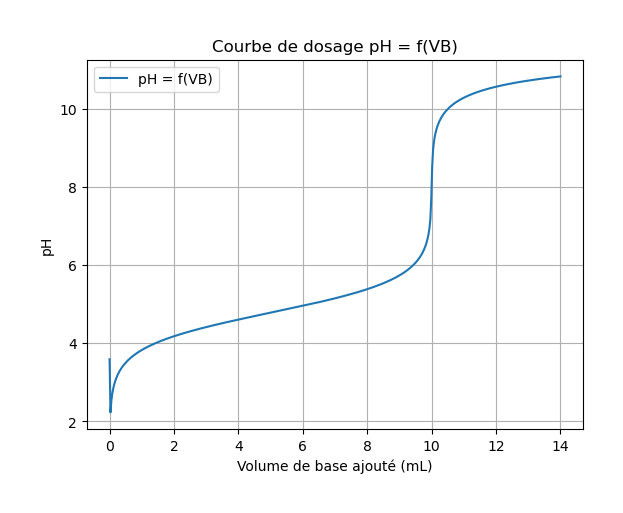

In [20]:
# Tracé de la courbe
plt.plot(VB, pH_values, label='pH = f(VB)')
plt.xlabel('Volume de base ajouté (mL)')
plt.ylabel('pH')
plt.title('Courbe de dosage pH = f(VB)')
plt.legend()
plt.grid()

In [23]:
pd.DataFrame({"VB":VB, "pH":pH_values}).to_csv("ph_vb.dat",sep=" ",index=False)